# 16 — PoC de Modelo Sequencial (GRU) para a Escavadeira (Sprint 12)

**Motivação:** Sprint 11 mostrou que o sinal existe na escavadeira (alarmes de lift 44×) mas é raro. Esta PoC testa se um modelo **sequencial** — que vê a ORDEM bruta dos alarmes — recupera esse sinal, onde o LightGBM agregado falha (Recall=0,14).

**Arquitetura:** `Embedding(alarmes) → GRU → Linear → sigmoid`. Cada decisão observa os 32 alarmes anteriores do equipamento. Split temporal do projeto (treino jan-abr / val Mai / teste Jun). Avaliação **honesta** no Jun completo (7,35M eventos, só 162 positivos).

In [1]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent
d = json.loads((ROOT / 'outputs' / 'gold' / 'escavadeira_gru.json').read_text())
fig_dir = ROOT / 'outputs' / 'figures'
print('Arquitetura:', d['architecture'])
print('Nota:', d['note_distribution_shift'])

Arquitetura: {'seq_len': 32, 'emb_dim': 24, 'hidden': 48, 'vocab_size': 300, 'epochs': 4, 'neg_ratio_train': 5}
Nota: Jun (teste) tem apenas 162 positivos vs ~108k no treino — mesmo shift severo do Sprint 5.


## 1. GRU sequencial vs. LightGBM geral — Teste Jun/2025

In [2]:
gm = d['test_metrics_gru']; bm = d['baseline_lgbm_escavadeira']
pd.DataFrame([
  {'Métrica':'Recall','GRU':round(gm['recall'],3),'LightGBM':round(bm['recall'],3),'Decisiva?':'enganoso'},
  {'Métrica':'Precision','GRU':round(gm['precision'],4),'LightGBM':round(bm['precision'],4),'Decisiva?':'GRU≈0'},
  {'Métrica':'F1','GRU':round(gm['F1'],4),'LightGBM':round(bm['F1'],4),'Decisiva?':'GRU pior'},
  {'Métrica':'PR-AUC','GRU':round(gm['PR_AUC'],4),'LightGBM':round(bm['PR_AUC'],4),'Decisiva?':'SIM → GRU pior'},
  {'Métrica':'ROC-AUC','GRU':round(gm['ROC_AUC'],3),'LightGBM':round(bm['ROC_AUC'],3),'Decisiva?':'GRU<0,5'},
])

,Métrica,GRU,LightGBM,Decisiva?
0,Recall,0.6850,0.1360,enganoso
1,Precision,0.0000,0.0081,GRU≈0
2,F1,0.0000,0.0153,GRU pior
3,PR-AUC,0.0002,0.0102,SIM → GRU pior
4,ROC-AUC,0.4290,0.7900,"GRU<0,5"


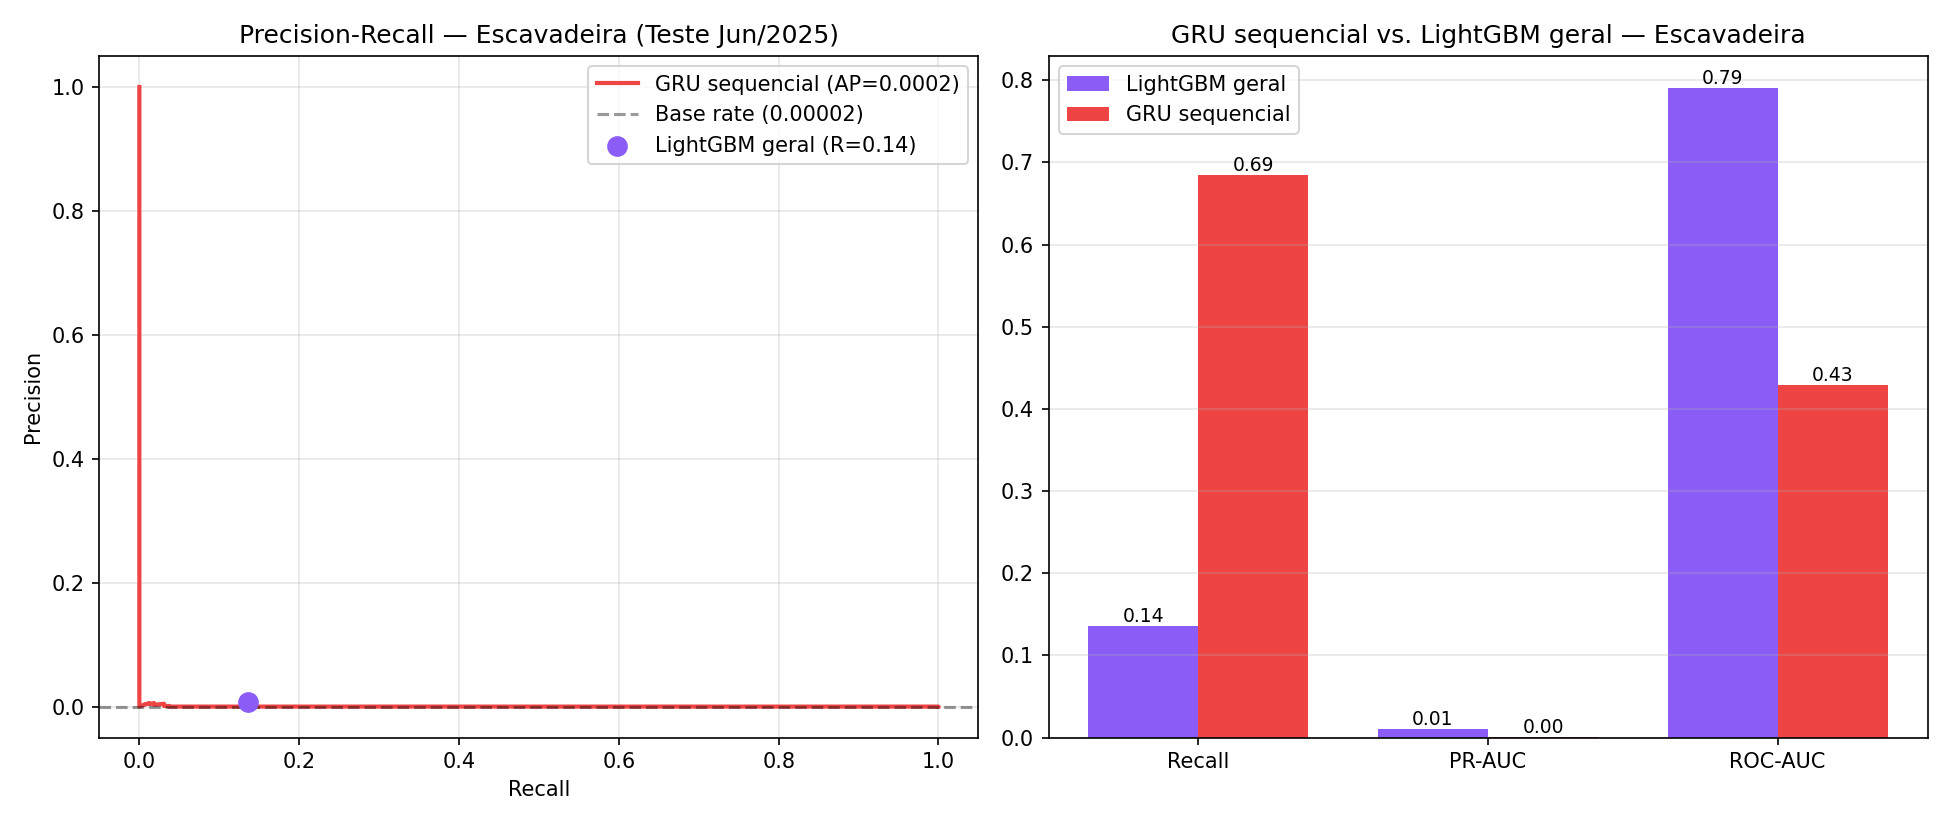

In [3]:
display(Image(filename=str(fig_dir / 'escavadeira_gru_vs_baseline.png')))

In [4]:
print(f"TP = {gm['TP']} de {gm['n_pos_test']} positivos reais")
print(f"FP = {gm['FP']:,} (de {gm['n_test']:,} eventos) -> modelo marca {gm['FP']/gm['n_test']:.0%} de tudo como positivo")
print(f"Supera baseline em Recall? {d['beats_baseline_recall']} | em PR-AUC? {d['beats_baseline_prauc']}")

TP = 111 de 162 positivos reais
FP = 6,639,489 (de 7,351,896 eventos) -> modelo marca 90% de tudo como positivo
Supera baseline em Recall? True | em PR-AUC? False


## 2. Interpretação — Resultado Negativo Inequívoco

**O Recall de 0,685 é um artefato, não um ganho.** Para atingi-lo, o GRU classifica **6,6 milhões** dos 7,35M eventos como positivos (precisão ≈ 0). As métricas que importam sob desbalanceamento extremo desmentem qualquer ganho:
- **PR-AUC = 0,0002** vs. 0,0102 do baseline → ~50× **pior**.
- **ROC-AUC = 0,43** → abaixo de 0,5, ranking **pior que o acaso**.

Durante o treino, a ROC-AUC de validação (Mai) ficou travada em ~0,44 mesmo com a perda de treino caindo (0,88 → 0,66): clássico overfit a padrões de Jan-Abr que **não transferem**.

## 3. Conclusão Triangulada

Três experimentos independentes convergem para o mesmo diagnóstico:

| Sprint | Abordagem | Resultado na escavadeira |
|---|---|---|
| 5 | Modelo LightGBM dedicado | Falhou (overfit precoce) |
| 8 | Detecção de drift | Variação 600× na taxa DG |
| 12 | Modelo sequencial GRU | Falhou (PR-AUC 0,0002) |

O Don't Go da escavadeira em Junho (162 eventos vs ~108k no treino) **não é aprendível** a partir do histórico Jan-Abr por nenhuma arquitetura — a distribuição mudou estruturalmente. **O gargalo é a não-estacionariedade dos dados, não a capacidade do modelo nem a representação das features.**

**Reorientação da solução** (do território de modelagem para o operacional):
1. Investigar o que mudou fisicamente na frota de escavadeiras entre Mai e Jun/2025.
2. Adotar re-treinamento adaptativo disparado pelo detector de drift do Sprint 8 — em vez de buscar um modelo estático mais sofisticado.

**Valor científico:** uma PoC de deep learning rigorosa que *não* funcionou, documentada com a métrica honesta (PR-AUC, não o Recall enganoso), é evidência de método — e fecha empiricamente a fronteira do que é possível com os dados atuais.